In [14]:
#1.Dataset Load
import pandas as pd
import matplotlib.pyplot as plt
df = pd.read_csv(r"C:\Users\shwet\Downloads\Amazon Sales.csv")
print(df.head())

   index             Order ID      Date                        Status  \
0      0  405-8078784-5731545  04-30-22                     Cancelled   
1      1  171-9198151-1101146  04-30-22  Shipped - Delivered to Buyer   
2      2  404-0687676-7273146  04-30-22                       Shipped   
3      3  403-9615377-8133951  04-30-22                     Cancelled   
4      4  407-1069790-7240320  04-30-22                       Shipped   

  Fulfilment Sales Channel ship-service-level  Category Size Courier Status  \
0   Merchant     Amazon.in           Standard   T-shirt    S     On the Way   
1   Merchant     Amazon.in           Standard     Shirt  3XL        Shipped   
2     Amazon     Amazon.in          Expedited     Shirt   XL        Shipped   
3   Merchant     Amazon.in           Standard   Blazzer    L     On the Way   
4     Amazon     Amazon.in          Expedited  Trousers  3XL        Shipped   

   ...  currency  Amount    ship-city   ship-state ship-postal-code  \
0  ...       IN

In [15]:
#2.Columns check
print(df.columns)
print(df.shape)

Index(['index', 'Order ID', 'Date', 'Status', 'Fulfilment', 'Sales Channel',
       'ship-service-level', 'Category', 'Size', 'Courier Status', 'Qty',
       'currency', 'Amount', 'ship-city', 'ship-state', 'ship-postal-code',
       'ship-country', 'B2B', 'fulfilled-by', 'New', 'PendingS'],
      dtype='object')
(128976, 21)


In [16]:
#3.Cleaning
print(df.isnull().sum())

index                      0
Order ID                   0
Date                       0
Status                     0
Fulfilment                 0
Sales Channel              0
ship-service-level         0
Category                   0
Size                       0
Courier Status             0
Qty                        0
currency                7800
Amount                  7800
ship-city                 35
ship-state                35
ship-postal-code          35
ship-country              35
B2B                        0
fulfilled-by           89713
New                   128976
PendingS              128976
dtype: int64


In [17]:
#4.Duplicate Remove 
df.drop_duplicates(inplace=True)

In [21]:
#5.Date convert
df['Date'] = pd.to_datetime(df['Date'].astype(str), errors='coerce', infer_datetime_format=True)
df = df.dropna(subset=['Date'])  # Drop invalid dates
df['Month'] = df['Date'].dt.month

C:\Users\shwet\AppData\Local\Temp\ipykernel_10020\3654816687.py:2: UserWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  df['Date'] = pd.to_datetime(df['Date'].astype(str), errors='coerce', infer_datetime_format=True)


In [13]:
#6.KPI Result
print("Total Sales =", df['Amount'].sum())
print("Total Orders =", df['Order ID'].nunique())
print("Average Order Value =", df['Amount'].mean())

Total Sales = 78496786.39000002
Total Orders = 120229
Average Order Value = 648.6319205248764


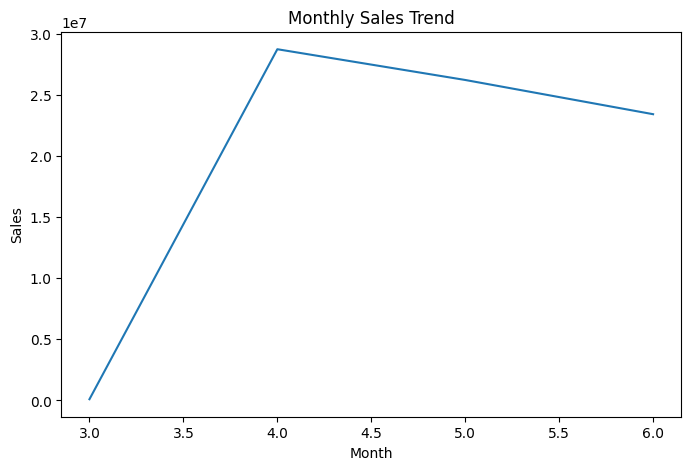

In [32]:
#7.Monthly Sales Trend
monthly_sales = df.groupby('Month')['Amount'].sum()

plt.figure(figsize=(8,5))
monthly_sales.plot(kind='line')
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.show()

**Insight:** Sales vary significantly across months, indicating seasonal demand patterns and fluctuating customer purchase behavior.

**Recommendation:** Plan promotional campaigns and inventory allocation before high-demand months to maximize revenue.


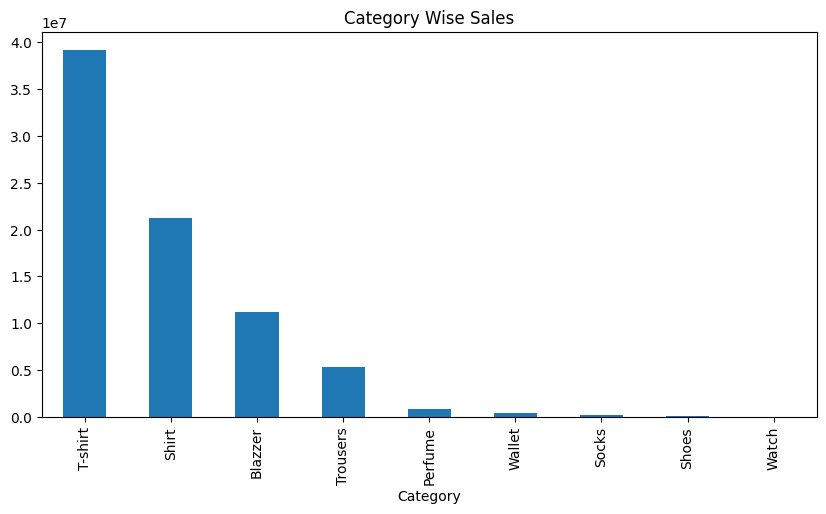

In [18]:
#8.Product Category Analysis
category_sales = df.groupby('Category')['Amount'].sum().sort_values(ascending=False)

plt.figure(figsize=(10,5))
category_sales.plot(kind='bar')
plt.title("Category Wise Sales")
plt.show()

**Insight:** A limited number of product categories contribute the majority of overall sales, showing concentrated customer preference.

**Recommendation:** Increase focus on high-performing categories while improving visibility of lower-performing categories through targeted offers.


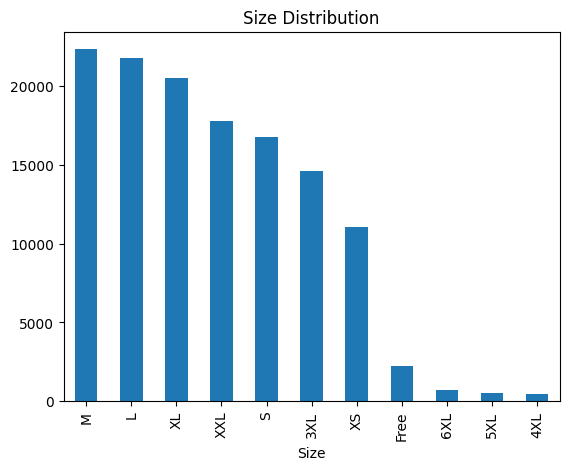

In [19]:
#9.Size Analysis 
df['Size'].value_counts().plot(kind='bar')
plt.title("Size Distribution")
plt.show()

**Insight:** Certain product sizes are purchased more frequently, reflecting customer size preference trends.

**Recommendation:** Maintain higher stock levels for frequently sold sizes to avoid stock shortages.


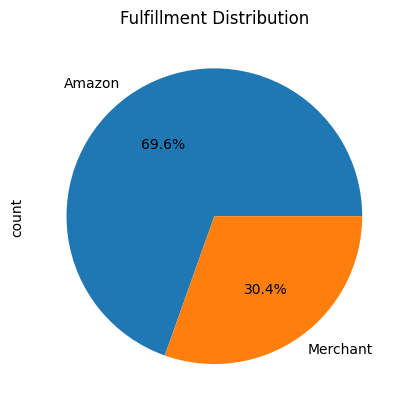

In [20]:
#10.Fulfilment Analysis 
df['Fulfilment'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title("Fulfillment Distribution")
plt.show()

**Insight:** Amazon fulfillment handles most orders efficiently, indicating stronger operational performance compared to alternative fulfillment
methods.

**Recommendation:** Strengthen the use of efficient fulfillment channels to improve delivery speed and customer satisfaction.


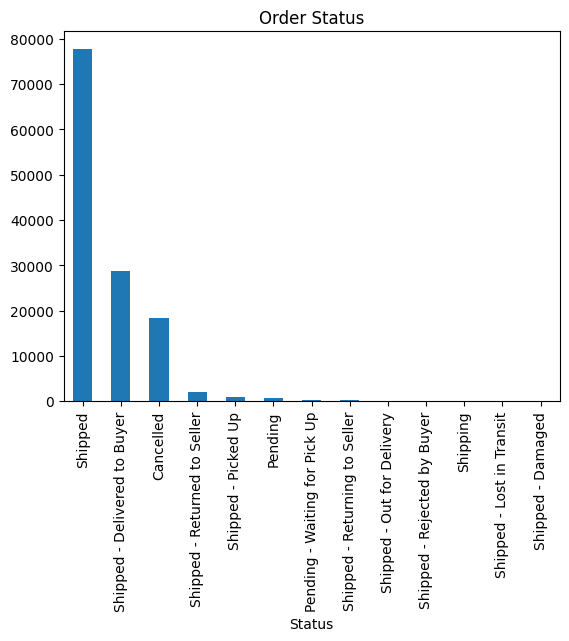

In [21]:
#11.Order Status Analysis
df['Status'].value_counts().plot(kind='bar')
plt.title("Order Status")
plt.show()

**Insight:** Most orders are successfully delivered, but cancelled and returned orders still affect overall efficiency.

**Recommendation:** Investigate cancellation causes and improve delivery coordination in affected areas.


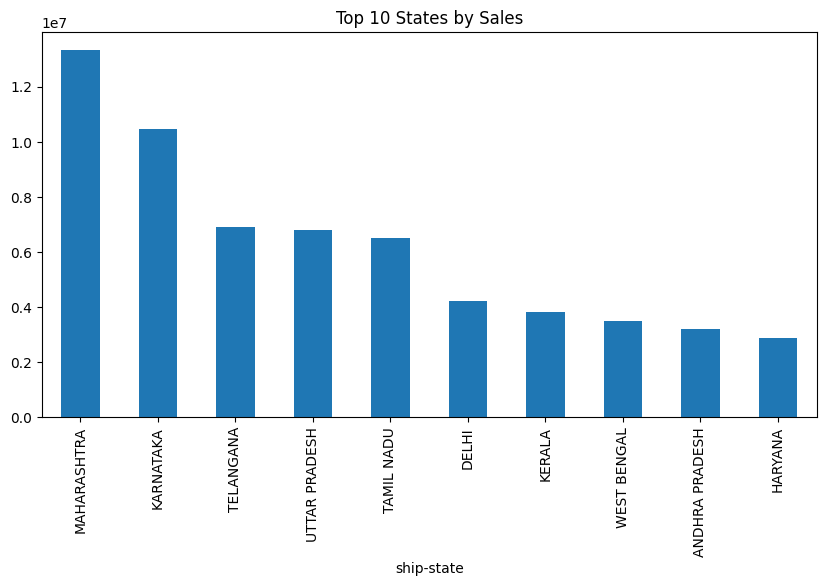

In [22]:
#12.State Wise Sales
state_sales = df.groupby('ship-state')['Amount'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,5))
state_sales.plot(kind='bar')
plt.title("Top 10 States by Sales")
plt.show()

**Insight:** Sales are concentrated in selected high-performing states, indicating strong regional demand.

**Recommendation:** Launch state-specific promotions and marketing campaigns in top revenue regions.


In [23]:
#13.Top Cities
print(df['ship-city'].value_counts().head(10))

ship-city
BENGALURU    11191
HYDERABAD     8067
MUMBAI        6115
NEW DELHI     5784
CHENNAI       5421
PUNE          3856
KOLKATA       2378
GURUGRAM      1865
THANE         1700
LUCKNOW       1458
Name: count, dtype: int64


**Insight:** A few major cities contribute a large portion of total orders.

**Recommendation:** Improve logistics and customer engagement in top-performing cities to sustain growth.


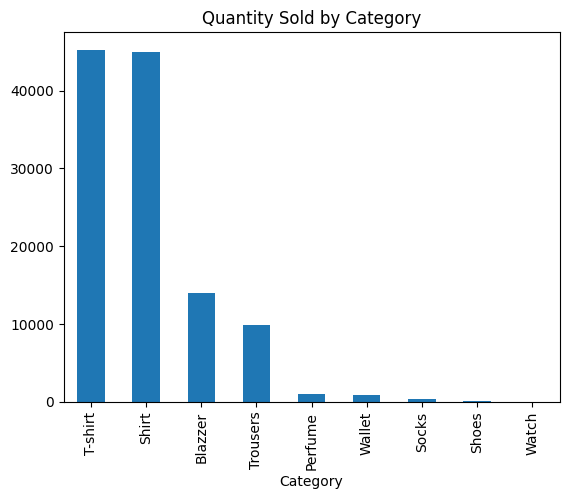

In [24]:
#14.Quantity Sold
qty = df.groupby('Category')['Qty'].sum().sort_values(ascending=False)

qty.plot(kind='bar')
plt.title("Quantity Sold by Category")
plt.show()

**Insight:** High quantity sales are associated with selected categories, showing repeated customer demand.

**Recommendation:** Prioritize inventory replenishment for high-volume products.


In [28]:
#15.B2B Analysis
print(df['B2B'].value_counts())

B2B
False    127937
True        871
Name: count, dtype: int64


**Insight:** Business-to-consumer orders dominate the dataset, while B2B transactions represent a smaller segment.

**Recommendation:** Explore B2B expansion opportunities through bulk offers and corporate partnerships.
